<a href="https://colab.research.google.com/github/21anonymous/Advance-nuclear-physics-lab-/blob/main/gamma_spectroscopy_efficiency_calculation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.8 MB/s eta 0:00:00


Saving 1.2 Cs.txt to 1.2 Cs.txt


Saving Cs.txt to Cs.txt
Enter the current activity of the source in Bq: 73e3
Enter the distance from detector to source in cm: 1.5
Enter decay fractions (comma-separated, one per peak): 0.85
Enter the measurement time in seconds: 5
Enter solid angles in steradians (comma-separated, matching files): 1.26


<ipython-input-1-f305faa4bf4b>:50: RuntimeWarning: invalid value encountered in scalar divide
  slope = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)


1.txt generated successfully


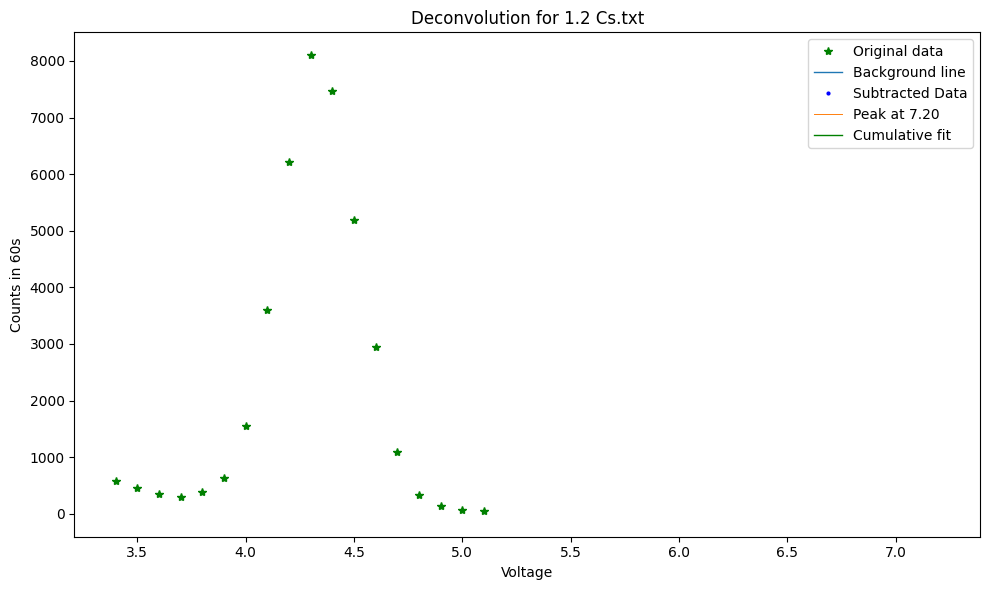

In [ ]:
# Gamma Spectroscopy Efficiency Calculation
!pip install google-colab

from google.colab import files as fil
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.signal import find_peaks
import math
from datetime import datetime

# Gaussian function
def gaussian(x, a, mean, sigma):
    return a * np.exp(-((x - mean) ** 2) / (2 * sigma**2))

# Sum of multiple Gaussians
def total_gaussian(x, amplitudes, means, sigmas):
    return sum(gaussian(x, a, m, s) for a, m, s in zip(amplitudes, means, sigmas))

# Chi-square minimization
def chi_square(params, x, y, y_err):
    n = len(means)
    amplitudes = params[:n]
    fitted_means = params[n:2*n]
    fitted_sigmas = params[2*n:]
    model = total_gaussian(x, amplitudes, fitted_means, fitted_sigmas)
    return np.sum(((y - model) / y_err) ** 2) / (len(y) - len(params))

# Read data from file
def read_data(file):
    x_data, y_data = [], []
    try:
        with open(file, "r") as f:
            for line in f:
                if line.strip():
                    columns = line.split()
                    if len(columns) >= 2:
                        x_data.append(float(columns[0]))
                        y_data.append(float(columns[1]))
                    else:
                        print(f"Warning: Skipping line (not enough data): {line.strip()}")
    except FileNotFoundError:
        print(f"Error: The file {file} was not found.")
        return np.array([]), np.array([])
    return np.array(x_data), np.array(y_data)

# Line fit for background subtraction
def line_fit(x, y):
    x_mean, y_mean = np.mean(x), np.mean(y)
    slope = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)
    intercept = y_mean - slope * x_mean
    return slope, intercept

# Upload files
uploaded1 = fil.upload()
under_block_file = list(uploaded1.keys())[0]
uploaded2 = fil.upload()
above_block_file = list(uploaded2.keys())[0]

files = [under_block_file, above_block_file]

# User inputs
activity = float(input("Enter the current activity of the source in Bq: "))
distance = float(input("Enter the distance from detector to source in cm: "))
decay_fraction = [float(i) for i in input("Enter decay fractions (comma-separated, one per peak): ").split(",")]
measurement_time = float(input("Enter the measurement time in seconds: "))
solid_angles = [float(i) for i in input("Enter solid angles in steradians (comma-separated, matching files): ").split(",")]

# Peak estimates
means = [7.2, 8.2]
sigmas = [0.18, 0.19]

# Decay correction (optional)
# start_date = datetime(2008, 4, 1)
# current_date = datetime.today()
# years_diff = (current_date - start_date).days / 365.25
# a0 = 15.91e4
# t_half = 5.2
# at = a0 * np.exp(-(0.693 * years_diff) / t_half)
at = activity

# Process each file
for file, solid_angle in zip(files, solid_angles):
    x_data, y_data_1 = read_data(file)
    y_err = np.sqrt(y_data_1)
    output = file.split('.')[0]

    peak_indices = [np.argmin(np.abs(x_data - m)) for m in means]
    window_size = 5
    background_indices = []
    for index in peak_indices:
        window_indices = range(max(0, index - window_size), min(len(x_data), index + window_size + 1))
        min_index_in_window = window_indices[np.argmin(y_data_1[window_indices])]
        background_indices.append(min_index_in_window)

    background_indices = sorted(list(set(background_indices)))
    x1 = x_data[background_indices]
    y1 = y_data_1[background_indices]

    slope, intercept = line_fit(x1, y1)
    y_background = slope * x_data + intercept
    y_data = np.maximum(y_data_1 - np.abs(y_background), 1e-5)

    plt.figure(figsize=(10, 6))
    plt.plot(x_data, y_data_1, "g*", label='Original data', linewidth=1)
    plt.plot(x_data, y_background, label='Background line', linewidth=1)

    p = [np.argmin(abs(x_data - m)) for m in means]
    peaks_new = y_data[p]

    mean_bounds = [(m - m*0.05, m + m*0.05) for m in means]
    sigma_bounds = [(s - s*0.10, s + s*0.10) for s in sigmas]
    amplitude_bounds = [(0, pv) for pv in peaks_new]
    initial_guess = np.concatenate([np.full(len(means), max(y_data)), means, sigmas])
    bounds = amplitude_bounds + mean_bounds + sigma_bounds

    result = minimize(chi_square, initial_guess, args=(x_data, y_data, y_err), method='L-BFGS-B', bounds=bounds)
    optimized_amplitudes = result.x[:len(means)]
    optimized_means = result.x[len(means):2*len(means)]
    optimized_sigmas = result.x[2*len(means):]

    y_bar = np.sqrt(y_data)
    plt.plot(x_data, y_data, "bo", label='Subtracted Data', markersize=2)
    plt.errorbar(x_data, y_data, yerr=y_bar, fmt="o", color="red", markersize=0.1, capsize=3)

    y_smooth = np.zeros(len(x_data) * 10)
    x_smooth = np.linspace(min(x_data), max(x_data), len(x_data) * 10)

    with open(output + ".txt", 'w') as out_file:
        out_file.write(f"{file}\n\n")
        out_file.write(f"Current Activity of the source = {at:.2f} Bq\n\n")

        for a, m, s, df in zip(optimized_amplitudes, optimized_means, optimized_sigmas, decay_fraction):
            y_new = gaussian(x_data, a, m, s)
            plt.plot(x_smooth, gaussian(x_smooth, a, m, s), linewidth=0.7, label=f'Peak at {m:.2f}')
            y_smooth += gaussian(x_smooth, a, m, s)
            area = np.sum(gaussian(x_data, a, m, s))
            abs_eff = area / (measurement_time * at * df)
            intrinsic_eff = abs_eff * ((4 * math.pi) / solid_angle)

            out_file.write(f"Area under Peak at {m:.2f} = {area/measurement_time:.2f} per second\n")
            out_file.write(f"Decay fraction = {df}\n")
            out_file.write(f"Solid angle = {solid_angle} sr\n")
            out_file.write(f"Absolute efficiency = {abs_eff * 100:.4f} %\n")
            out_file.write(f"Intrinsic efficiency = {intrinsic_eff * 100:.4f} %\n\n")

            out_file.write("#Voltage;Count;Background;Subtracted;Fitted\n")
            for i in range(len(x_data)):
                out_file.write(f"{x_data[i]:.1f};{y_data_1[i]:.0f};{y_background[i]:.0f};{y_data[i]:.0f};{y_new[i]:.0f}\n")

            plt.plot([m, m], [0, a], linestyle='--', linewidth=0.5)

    plt.plot(x_smooth, y_smooth, label='Cumulative fit', color='green', linewidth=1)
    plt.xlabel('Voltage')
    plt.ylabel('Counts in 60s')
    plt.title(f'Deconvolution for {file}')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"60Co_solid_angle_{solid_angle}.png", format='png', dpi=300)
    print(f"{output}.txt generated successfully")

plt.show()

Saving 1.2 Cs.txt to 1.2 Cs (1).txt
Enter the current activity of the source in Bq: 73e3
Enter the distance from detector to source in cm: 105
Enter decay fractions (comma-separated, one per peak): 0.855
Enter the measurement time in seconds: 60
Enter solid angle in steradians: 1.23

File: 1.2 Cs (1).txt
Activity: 73000.00 Bq

Peak at 7.20 keV:
  Area = 0.00 counts/sec
  Decay fraction = 0.855
  Absolute efficiency = 0.0000%
  Intrinsic efficiency = 0.0000%



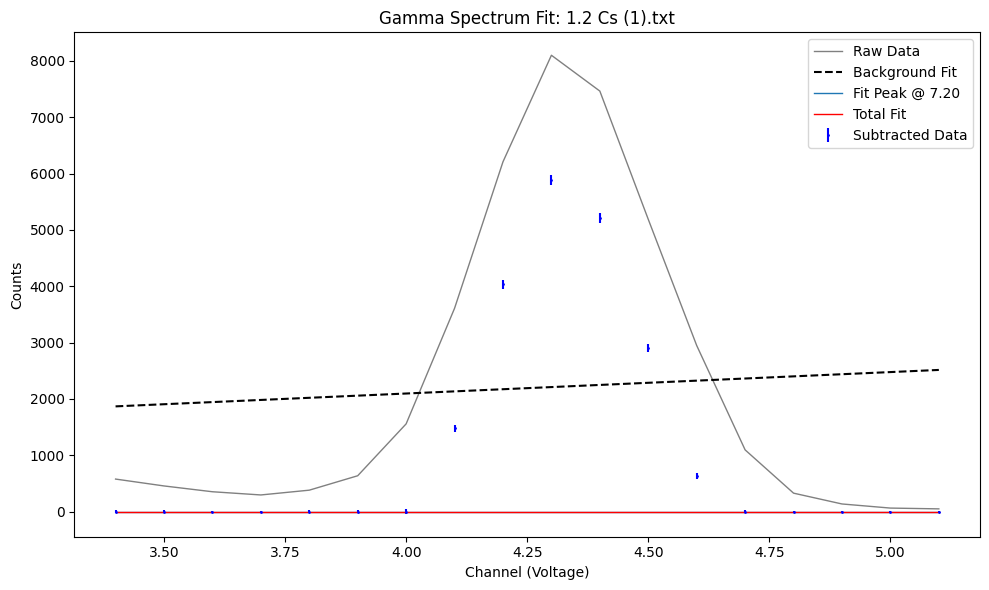

In [ ]:
# Gamma Spectroscopy Efficiency Calculation (Single File)

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import math
from google.colab import files as fil

# Gaussian function
def gaussian(x, a, mean, sigma):
    return a * np.exp(-((x - mean) ** 2) / (2 * sigma**2))

# Sum of multiple Gaussians
def total_gaussian(x, amplitudes, means, sigmas):
    return sum(gaussian(x, a, m, s) for a, m, s in zip(amplitudes, means, sigmas))

# Chi-square minimization
def chi_square(params, x, y, y_err):
    n = len(y_err)
    amplitudes = params[:len(means)]
    fitted_means = params[len(means):2*len(means)]
    fitted_sigmas = params[2*len(means):]
    model = total_gaussian(x, amplitudes, fitted_means, fitted_sigmas)
    return np.sum(((y - model) / y_err) ** 2) / (len(y) - len(params))

# Read data from file
def read_data(file):
    x_data, y_data = [], []
    with open(file, "r") as f:
        for line in f:
            if line.strip():
                columns = line.split()
                if len(columns) >= 2:
                    x_data.append(float(columns[0]))
                    y_data.append(float(columns[1]))
    return np.array(x_data), np.array(y_data)

# Background line fit
def line_fit(x, y):
    A = np.vstack([x, np.ones(len(x))]).T
    m, c = np.linalg.lstsq(A, y, rcond=None)[0]
    return m, c

# File upload
uploaded = fil.upload()
file = list(uploaded.keys())[0]

# User inputs
activity = float(input("Enter the current activity of the source in Bq: "))
distance = float(input("Enter the distance from detector to source in cm: "))
decay_fraction = [float(i) for i in input("Enter decay fractions (comma-separated, one per peak): ").split(",")]
measurement_time = float(input("Enter the measurement time in seconds: "))
solid_angle = float(input("Enter solid angle in steradians: "))

# Peak estimates
means = [7.2, 8.2]
sigmas = [0.18, 0.19]

# Read and preprocess data
x_data, y_data_raw = read_data(file)
y_err = np.sqrt(np.maximum(y_data_raw, 1e-5))

# Estimate background
non_peak_mask = np.ones_like(x_data, dtype=bool)
for m in means:
    non_peak_mask &= ((x_data < m - 0.4) | (x_data > m + 0.4))

x_bg = x_data[non_peak_mask]
y_bg = y_data_raw[non_peak_mask]
slope, intercept = line_fit(x_bg, y_bg)
y_background = slope * x_data + intercept
y_subtracted = np.maximum(y_data_raw - y_background, 1e-5)

# Plot raw and background
plt.figure(figsize=(10, 6))
plt.plot(x_data, y_data_raw, label='Raw Data', color='gray', linewidth=1)
plt.plot(x_data, y_background, label='Background Fit', color='black', linestyle='--')

# Initial guess and bounds
p = [np.argmin(abs(x_data - m)) for m in means]
peaks_guess = y_subtracted[p]
mean_bounds = [(m - m*0.05, m + m*0.05) for m in means]
sigma_bounds = [(s - s*0.10, s + s*0.10) for s in sigmas]
amplitude_bounds = [(0, pv) for pv in peaks_guess]
initial_guess = np.concatenate([peaks_guess, means, sigmas])
bounds = amplitude_bounds + mean_bounds + sigma_bounds

# Fit
result = minimize(chi_square, initial_guess, args=(x_data, y_subtracted, y_err), method='L-BFGS-B', bounds=bounds)
optimized_amplitudes = result.x[:len(means)]
optimized_means = result.x[len(means):2*len(means)]
optimized_sigmas = result.x[2*len(means):]

# Plot subtracted data with fit
plt.errorbar(x_data, y_subtracted, yerr=y_err, fmt='.', label='Subtracted Data', color='blue', markersize=2)
x_smooth = np.linspace(min(x_data), max(x_data), 1000)
y_smooth_total = np.zeros_like(x_smooth)

print(f"\nFile: {file}")
print(f"Activity: {activity:.2f} Bq\n")
for a, m, s, df in zip(optimized_amplitudes, optimized_means, optimized_sigmas, decay_fraction):
    y_fit = gaussian(x_smooth, a, m, s)
    plt.plot(x_smooth, y_fit, label=f'Fit Peak @ {m:.2f}', linewidth=1)
    y_smooth_total += y_fit

    area = np.sum(gaussian(x_data, a, m, s))
    abs_eff = area / (measurement_time * activity * df)
    intrinsic_eff = abs_eff * ((4 * math.pi) / solid_angle)

    print(f"Peak at {m:.2f} keV:")
    print(f"  Area = {area/measurement_time:.2f} counts/sec")
    print(f"  Decay fraction = {df}")
    print(f"  Absolute efficiency = {abs_eff*100:.4f}%")
    print(f"  Intrinsic efficiency = {intrinsic_eff*100:.4f}%\n")

plt.plot(x_smooth, y_smooth_total, label='Total Fit', color='red', linewidth=1)
plt.xlabel('Channel (Voltage)')
plt.ylabel('Counts')
plt.title(f'Gamma Spectrum Fit: {file}')
plt.legend()
plt.tight_layout()
plt.show()


Saving 1.2 Ba.txt to 1.2 Ba.txt
Enter the current activity of the source in Bq: 73e3
Enter decay fractions (comma-separated, one per peak): 0.866
Enter the measurement time in seconds: 60
Enter solid angle in steradians: 1.23

File: 1.2 Ba.txt
Activity: 73000.00 Bq

Peak at 7.20:
  Area = 0.00 counts/sec
  Decay fraction = 0.866
  Absolute efficiency = 0.0000%
  Intrinsic efficiency = 0.0000%



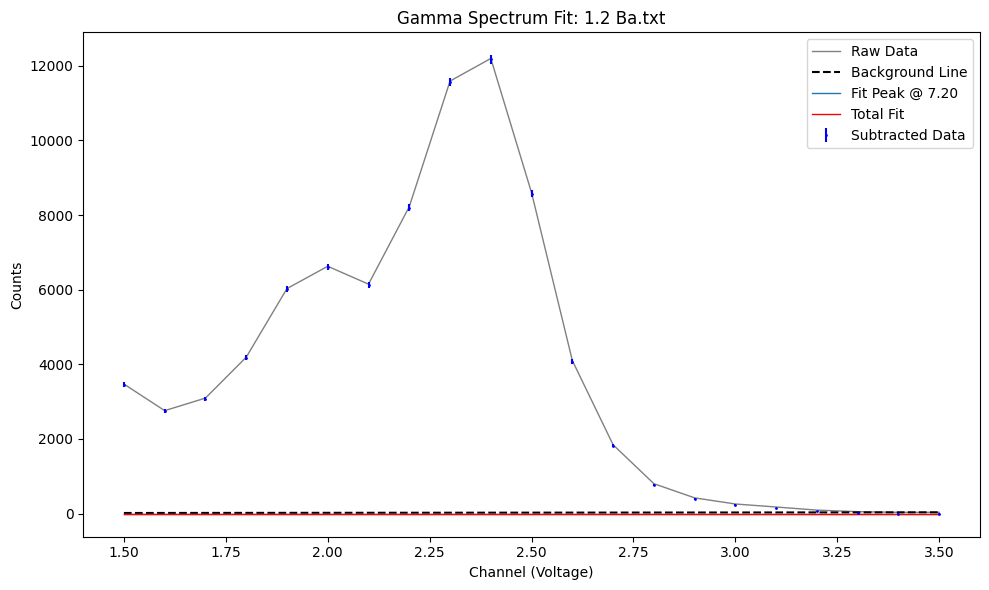

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import math
from google.colab import files as fil

# Gaussian function
def gaussian(x, a, mean, sigma):
    return a * np.exp(-((x - mean) ** 2) / (2 * sigma**2))

# Sum of multiple Gaussians
def total_gaussian(x, amplitudes, means, sigmas):
    return sum(gaussian(x, a, m, s) for a, m, s in zip(amplitudes, means, sigmas))

# Chi-square minimization
def chi_square(params, x, y, y_err):
    amplitudes = params[:len(means)]
    fitted_means = params[len(means):2*len(means)]
    fitted_sigmas = params[2*len(means):]
    model = total_gaussian(x, amplitudes, fitted_means, fitted_sigmas)
    return np.sum(((y - model) / y_err) ** 2)

# Read data from file
def read_data(file):
    x_data, y_data = [], []
    with open(file, "r") as f:
        for line in f:
            if line.strip():
                columns = line.split()
                if len(columns) >= 2:
                    x_data.append(float(columns[0]))
                    y_data.append(float(columns[1]))
    return np.array(x_data), np.array(y_data)

# Background line fit
def line_fit(x, y):
    A = np.vstack([x, np.ones(len(x))]).T
    m, c = np.linalg.lstsq(A, y, rcond=None)[0]
    return m, c

# File upload
uploaded = fil.upload()
file = list(uploaded.keys())[0]

# User inputs
activity = float(input("Enter the current activity of the source in Bq: "))
decay_fraction = [float(i) for i in input("Enter decay fractions (comma-separated, one per peak): ").split(",")]
measurement_time = float(input("Enter the measurement time in seconds: "))
solid_angle = float(input("Enter solid angle in steradians: "))

# Peak estimates
means = [7.2, 8.2]
sigmas = [0.18, 0.19]

# Read and preprocess data
x_data, y_data_raw = read_data(file)
y_err = np.sqrt(np.maximum(y_data_raw, 1e-5))

# Determine background points (lowest counts near each peak)
background_points = []
window_size = 5
for m in means:
    idx_peak = np.argmin(np.abs(x_data - m))
    start = max(0, idx_peak - window_size)
    end = min(len(x_data), idx_peak + window_size)
    idx_min = start + np.argmin(y_data_raw[start:end])
    background_points.append(idx_min)

background_points = list(set(background_points))
background_points.sort()
x_bg = x_data[background_points]
y_bg = y_data_raw[background_points]

# Background fit
slope, intercept = line_fit(x_bg, y_bg)
y_background = slope * x_data + intercept

# Subtract background
y_subtracted = np.maximum(y_data_raw - y_background, 1e-5)

# Plot raw and background
plt.figure(figsize=(10, 6))
plt.plot(x_data, y_data_raw, label='Raw Data', color='gray', linewidth=1)
plt.plot(x_data, y_background, label='Background Line', color='black', linestyle='--')

# Initial guess and bounds
p = [np.argmin(np.abs(x_data - m)) for m in means]
peaks_guess = y_subtracted[p]
mean_bounds = [(m - m*0.05, m + m*0.05) for m in means]
sigma_bounds = [(s - s*0.10, s + s*0.10) for s in sigmas]
amplitude_bounds = [(0, pv) for pv in peaks_guess]
initial_guess = np.concatenate([peaks_guess, means, sigmas])
bounds = amplitude_bounds + mean_bounds + sigma_bounds

# Fit
result = minimize(chi_square, initial_guess, args=(x_data, y_subtracted, y_err), method='L-BFGS-B', bounds=bounds)
optimized_amplitudes = result.x[:len(means)]
optimized_means = result.x[len(means):2*len(means)]
optimized_sigmas = result.x[2*len(means):]

# Plot subtracted data and fits
plt.errorbar(x_data, y_subtracted, yerr=y_err, fmt='.', label='Subtracted Data', color='blue', markersize=2)
x_smooth = np.linspace(min(x_data), max(x_data), 1000)
y_smooth_total = np.zeros_like(x_smooth)

print(f"\nFile: {file}")
print(f"Activity: {activity:.2f} Bq\n")
for a, m, s, df in zip(optimized_amplitudes, optimized_means, optimized_sigmas, decay_fraction):
    y_fit = gaussian(x_smooth, a, m, s)
    plt.plot(x_smooth, y_fit, label=f'Fit Peak @ {m:.2f}', linewidth=1)
    y_smooth_total += y_fit

    area = np.sum(gaussian(x_data, a, m, s))
    abs_eff = area / (measurement_time * activity * df)
    intrinsic_eff = abs_eff * ((4 * math.pi) / solid_angle)

    print(f"Peak at {m:.2f}:")
    print(f"  Area = {area/measurement_time:.2f} counts/sec")
    print(f"  Decay fraction = {df}")
    print(f"  Absolute efficiency = {abs_eff*100:.4f}%")
    print(f"  Intrinsic efficiency = {intrinsic_eff*100:.4f}%\n")

plt.plot(x_smooth, y_smooth_total, label='Total Fit', color='red', linewidth=1)
plt.xlabel('Channel (Voltage)')
plt.ylabel('Counts')
plt.title(f'Gamma Spectrum Fit: {file}')
plt.legend()
plt.tight_layout()
plt.show()


Saving 1.2 Ba.txt to 1.2 Ba (3).txt
Enter the current activity of the source in Bq: 73000
Enter decay fractions (comma-separated, one per peak): 0.85
Enter the measurement time in seconds: 60
Enter solid angle in steradians: 1.25
Enter approximate peak positions (comma-separated): 2.4
Enter approximate sigmas (comma-separated, same order as peaks): 0.5

File: 1.2 Ba (3).txt
Activity: 73000.00 Bq

Peak at 2.32:
  Area = 84.72 counts/sec
  Decay fraction = 0.85
  Absolute efficiency = 0.1365%
  Intrinsic efficiency = 1.3727%



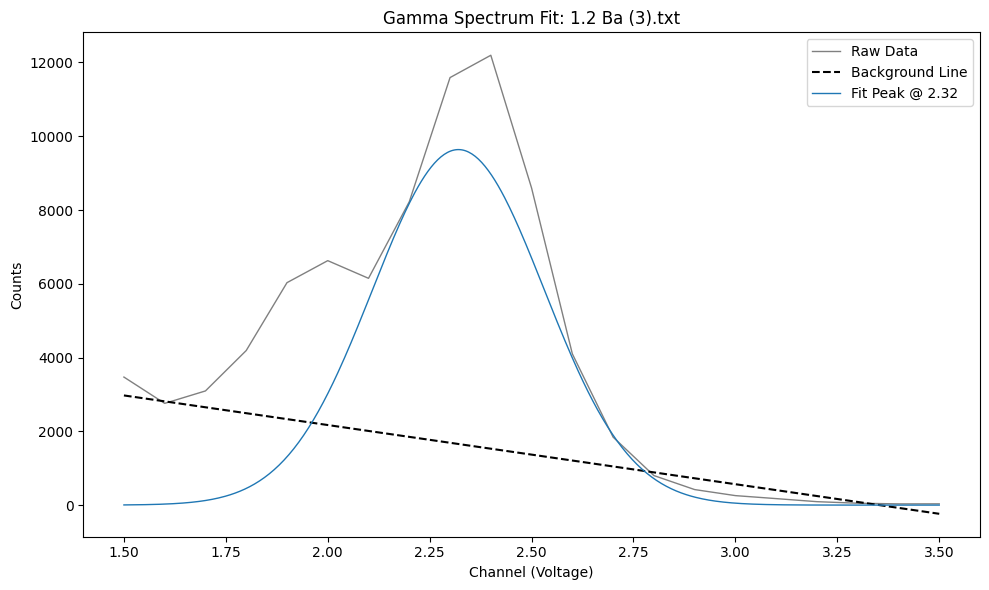

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import math
from google.colab import files as fil

# Gaussian function
def gaussian(x, a, mean, sigma):
    return a * np.exp(-((x - mean) ** 2) / (2 * sigma ** 2))

# Read data from file
def read_data(file):
    x_data, y_data = [], []
    with open(file, "r") as f:
        for line in f:
            if line.strip():
                columns = line.split()
                if len(columns) >= 2:
                    x_data.append(float(columns[0]))
                    y_data.append(float(columns[1]))
    return np.array(x_data), np.array(y_data)

# File upload
uploaded = fil.upload()
file = list(uploaded.keys())[0]

# User inputs
activity = float(input("Enter the current activity of the source in Bq: "))
decay_fraction = [float(i) for i in input("Enter decay fractions (comma-separated, one per peak): ").split(",")]
measurement_time = float(input("Enter the measurement time in seconds: "))
solid_angle = float(input("Enter solid angle in steradians: "))

# Peak estimate inputs
means = [float(i) for i in input("Enter approximate peak positions (comma-separated): ").split(",")]
sigmas = [float(i) for i in input("Enter approximate sigmas (comma-separated, same order as peaks): ").split(",")]

# Read and preprocess data
x_data, y_data_raw = read_data(file)
y_err = np.sqrt(np.maximum(y_data_raw, 1e-5))

# Estimate background from the lowest points
lowest_indices = np.argsort(y_data_raw)[:10]
x_bg = x_data[lowest_indices]
y_bg = y_data_raw[lowest_indices]

# Fit background line
coeffs = np.polyfit(x_bg, y_bg, 1)
y_background = np.polyval(coeffs, x_data)

# Subtract background
y_subtracted = np.maximum(y_data_raw - y_background, 1e-5)

# Plot raw data and background
plt.figure(figsize=(10, 6))
plt.plot(x_data, y_data_raw, label='Raw Data', color='gray', linewidth=1)
plt.plot(x_data, y_background, label='Background Line', color='black', linestyle='--')

# Fit Gaussian to each peak and calculate area
print(f"\nFile: {file}")
print(f"Activity: {activity:.2f} Bq\n")

for idx, (mean_est, sigma_est, df) in enumerate(zip(means, sigmas, decay_fraction)):
    mask = (x_data > mean_est - 3 * sigma_est) & (x_data < mean_est + 3 * sigma_est)
    x_fit = x_data[mask]
    y_fit = y_subtracted[mask]

    popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=[max(y_fit), mean_est, sigma_est])

    a_opt, mean_opt, sigma_opt = popt
    area = a_opt * sigma_opt * np.sqrt(2 * np.pi)

    abs_eff = area / (measurement_time * activity * df)
    intrinsic_eff = abs_eff * (4 * math.pi / solid_angle)

    # Plot the Gaussian fit
    x_smooth = np.linspace(min(x_fit), max(x_fit), 500)
    y_smooth = gaussian(x_smooth, *popt)
    plt.plot(x_smooth, y_smooth, label=f'Fit Peak @ {mean_opt:.2f}', linewidth=1)

    print(f"Peak at {mean_opt:.2f}:")
    print(f"  Area = {area/measurement_time:.2f} counts/sec")
    print(f"  Decay fraction = {df}")
    print(f"  Absolute efficiency = {abs_eff*100:.4f}%")
    print(f"  Intrinsic efficiency = {intrinsic_eff*100:.4f}%\n")

plt.xlabel('Channel (Voltage)')
plt.ylabel('Counts')
plt.title(f'Gamma Spectrum Fit: {file}')
plt.legend()
plt.tight_layout()
plt.show()


Saving 1.2 Cs.txt to 1.2 Cs (2).txt
Enter the current activity of the source in Bq: 73000
Enter decay fractions (comma-separated, one per peak): 0.85
Enter the measurement time in seconds: 60
Enter solid angle in steradians: 1.23
Enter approximate peak positions (comma-separated): 4.3
Enter approximate sigmas (comma-separated, same order as peaks): 0.5

File: 1.2 Cs (2).txt
Activity: 73000.00 Bq

Peak at 4.33:
  Area = 57.65 counts/sec
  Decay fraction = 0.85
  Absolute efficiency = 0.0929%
  Intrinsic efficiency = 0.9493%



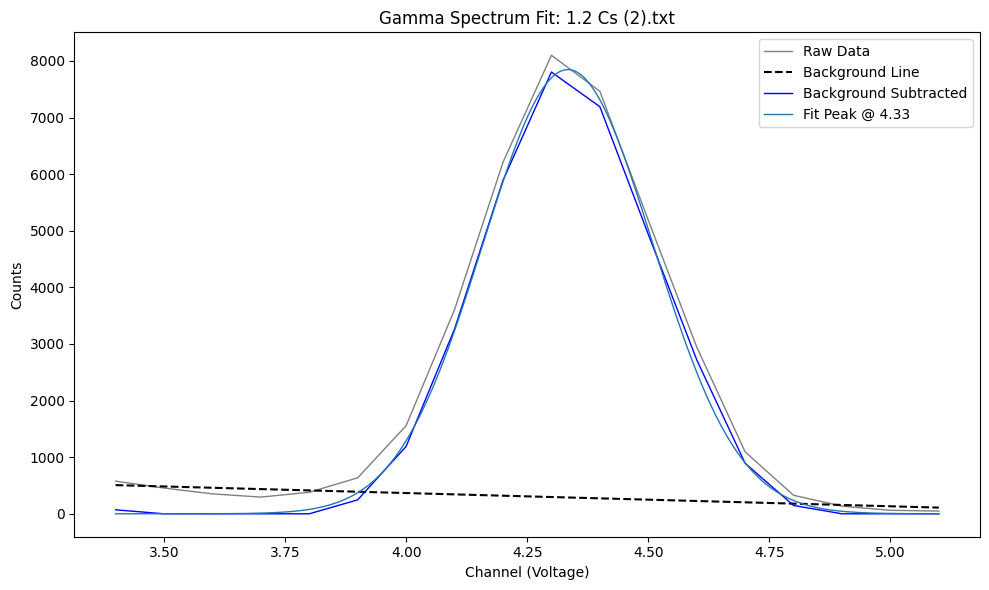

In [ ]:
# Gamma Spectroscopy Efficiency Calculation (Single File)

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import math
from google.colab import files as fil

# Gaussian function
def gaussian(x, a, mean, sigma):
    return a * np.exp(-((x - mean) ** 2) / (2 * sigma ** 2))

# Read data from file
def read_data(file):
    x_data, y_data = [], []
    with open(file, "r") as f:
        for line in f:
            if line.strip():
                columns = line.split()
                if len(columns) >= 2:
                    x_data.append(float(columns[0]))
                    y_data.append(float(columns[1]))
    return np.array(x_data), np.array(y_data)

# File upload
uploaded = fil.upload()
file = list(uploaded.keys())[0]

# User inputs
activity = float(input("Enter the current activity of the source in Bq: "))
decay_fraction = [float(i) for i in input("Enter decay fractions (comma-separated, one per peak): ").split(",")]
measurement_time = float(input("Enter the measurement time in seconds: "))
solid_angle = float(input("Enter solid angle in steradians: "))

# Peak estimate inputs
means = [float(i) for i in input("Enter approximate peak positions (comma-separated): ").split(",")]
sigmas = [float(i) for i in input("Enter approximate sigmas (comma-separated, same order as peaks): ").split(",")]

# Read and preprocess data
x_data, y_data_raw = read_data(file)
y_err = np.sqrt(np.maximum(y_data_raw, 1e-5))

# Estimate background from the lowest points
lowest_indices = np.argsort(y_data_raw)[:10]
x_bg = x_data[lowest_indices]
y_bg = y_data_raw[lowest_indices]

# Fit background line
coeffs = np.polyfit(x_bg, y_bg, 1)
y_background = np.polyval(coeffs, x_data)

# Subtract background
y_subtracted = np.maximum(y_data_raw - y_background, 1e-5)

# Plot raw data and background
plt.figure(figsize=(10, 6))
plt.plot(x_data, y_data_raw, label='Raw Data', color='gray', linewidth=1)
plt.plot(x_data, y_background, label='Background Line', color='black', linestyle='--')
plt.plot(x_data, y_subtracted, label='Background Subtracted', color='blue', linewidth=1)

# Fit Gaussian to each peak and calculate area
print(f"\nFile: {file}")
print(f"Activity: {activity:.2f} Bq\n")

for idx, (mean_est, sigma_est, df) in enumerate(zip(means, sigmas, decay_fraction)):
    mask = (x_data > mean_est - 3 * sigma_est) & (x_data < mean_est + 3 * sigma_est)
    x_fit = x_data[mask]
    y_fit = y_subtracted[mask]

    popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=[max(y_fit), mean_est, sigma_est])

    a_opt, mean_opt, sigma_opt = popt
    area = a_opt * sigma_opt * np.sqrt(2 * np.pi)

    abs_eff = area / (measurement_time * activity * df)
    intrinsic_eff = abs_eff * (4 * math.pi / solid_angle)

    # Plot the Gaussian fit
    x_smooth = np.linspace(min(x_fit), max(x_fit), 500)
    y_smooth = gaussian(x_smooth, *popt)
    plt.plot(x_smooth, y_smooth, label=f'Fit Peak @ {mean_opt:.2f}', linewidth=1)

    print(f"Peak at {mean_opt:.2f}:")
    print(f"  Area = {area/measurement_time:.2f} counts/sec")
    print(f"  Decay fraction = {df}")
    print(f"  Absolute efficiency = {abs_eff*100:.4f}%")
    print(f"  Intrinsic efficiency = {intrinsic_eff*100:.4f}%\n")

plt.xlabel('Channel (Voltage)')
plt.ylabel('Counts')
plt.title(f'Gamma Spectrum Fit: {file}')
plt.legend()
plt.tight_layout()
plt.show()

Saving 1.2 Cs.txt to 1.2 Cs (3).txt
Enter the current activity of the source in Bq: 73000
Enter decay fractions (comma-separated, one per peak): 0.85
Enter the measurement time in seconds: 60
Enter solid angle in steradians: 1.23
Enter approximate peak positions (comma-separated): 4.33
Enter approximate sigmas (comma-separated, same order as peaks): 0.23

File: 1.2 Cs (3).txt
Activity: 73000.00 Bq

Peak at 4.33:
  Area = 57.65 counts/sec
  Decay fraction = 0.85
  Absolute efficiency = 0.0929%
  Intrinsic efficiency = 0.9493%



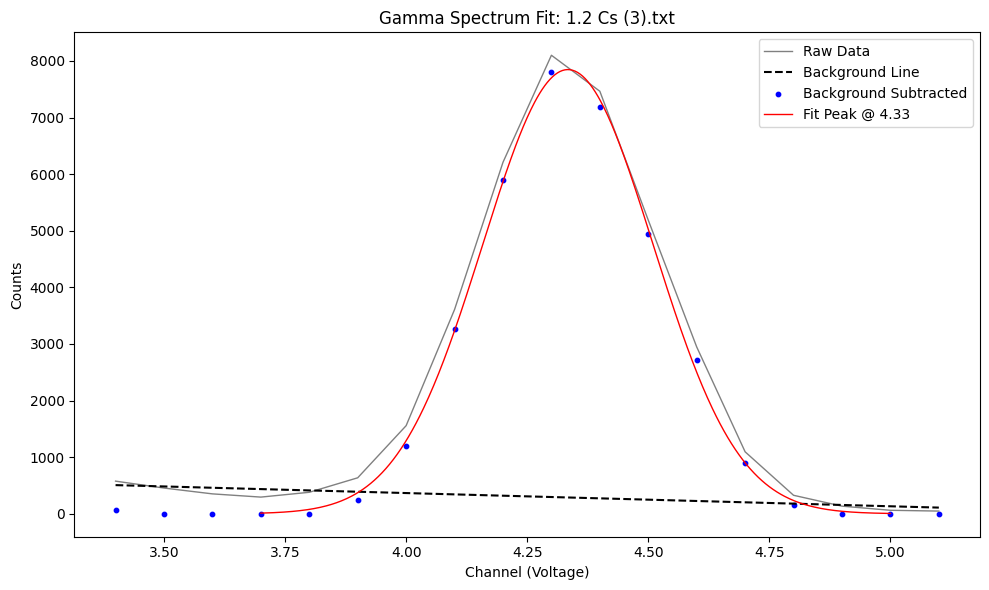

In [ ]:
# Gamma Spectroscopy Efficiency Calculation (Single File)

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import math
from google.colab import files as fil

# Gaussian function
def gaussian(x, a, mean, sigma):
    return a * np.exp(-((x - mean) ** 2) / (2 * sigma ** 2))

# Read data from file
def read_data(file):
    x_data, y_data = [], []
    with open(file, "r") as f:
        for line in f:
            if line.strip():
                columns = line.split()
                if len(columns) >= 2:
                    x_data.append(float(columns[0]))
                    y_data.append(float(columns[1]))
    return np.array(x_data), np.array(y_data)

# File upload
uploaded = fil.upload()
file = list(uploaded.keys())[0]

# User inputs
activity = float(input("Enter the current activity of the source in Bq: "))
decay_fraction = [float(i) for i in input("Enter decay fractions (comma-separated, one per peak): ").split(",")]
measurement_time = float(input("Enter the measurement time in seconds: "))
solid_angle = float(input("Enter solid angle in steradians: "))

# Peak estimate inputs
means = [float(i) for i in input("Enter approximate peak positions (comma-separated): ").split(",")]
sigmas = [float(i) for i in input("Enter approximate sigmas (comma-separated, same order as peaks): ").split(",")]

# Read and preprocess data
x_data, y_data_raw = read_data(file)
y_err = np.sqrt(np.maximum(y_data_raw, 1e-5))

# Estimate background from the lowest points
lowest_indices = np.argsort(y_data_raw)[:10]
x_bg = x_data[lowest_indices]
y_bg = y_data_raw[lowest_indices]

# Fit background line
coeffs = np.polyfit(x_bg, y_bg, 1)
y_background = np.polyval(coeffs, x_data)

# Subtract background
y_subtracted = np.maximum(y_data_raw - y_background, 1e-5)

# Plot raw data and background
plt.figure(figsize=(10, 6))
plt.plot(x_data, y_data_raw, label='Raw Data', color='gray', linewidth=1)
plt.plot(x_data, y_background, label='Background Line', color='black', linestyle='--')
plt.scatter(x_data, y_subtracted, label='Background Subtracted', color='blue', s=10, marker='o')

# Fit Gaussian to each peak and calculate area
print(f"\nFile: {file}")
print(f"Activity: {activity:.2f} Bq\n")

colors = ['red', 'green', 'purple', 'orange', 'brown']  # for plotting individual peaks

for idx, (mean_est, sigma_est, df) in enumerate(zip(means, sigmas, decay_fraction)):
    mask = (x_data > mean_est - 3 * sigma_est) & (x_data < mean_est + 3 * sigma_est)
    x_fit = x_data[mask]
    y_fit = y_subtracted[mask]

    popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=[max(y_fit), mean_est, sigma_est])

    a_opt, mean_opt, sigma_opt = popt
    area = a_opt * sigma_opt * np.sqrt(2 * np.pi)

    abs_eff = area / (measurement_time * activity * df)
    intrinsic_eff = abs_eff * (4 * math.pi / solid_angle)

    # Plot the Gaussian fit
    x_smooth = np.linspace(min(x_fit), max(x_fit), 500)
    y_smooth = gaussian(x_smooth, *popt)
    plt.plot(x_smooth, y_smooth, label=f'Fit Peak @ {mean_opt:.2f}', linewidth=1, color=colors[idx % len(colors)])

    print(f"Peak at {mean_opt:.2f}:")
    print(f"  Area = {area/measurement_time:.2f} counts/sec")
    print(f"  Decay fraction = {df}")
    print(f"  Absolute efficiency = {abs_eff*100:.4f}%")
    print(f"  Intrinsic efficiency = {intrinsic_eff*100:.4f}%\n")

plt.xlabel('Channel (Voltage)')
plt.ylabel('Counts')
plt.title(f'Gamma Spectrum Fit: {file}')
plt.legend()
plt.tight_layout()
plt.show()


Saving Na.txt to Na (2).txt
Enter the current activity of the source in Bq: 28020
Enter decay fractions (comma-separated, one per peak): 0.9994
Enter the measurement time in seconds: 60
Enter solid angle in steradians: 2.11
Enter approximate peak positions (comma-separated): 7.8
Enter approximate sigmas (comma-separated, same order as peaks): 0.2

File: Na (2).txt
Activity: 28020.00 Bq

Peak at 7.84:
  Area (total counts under peak) = 1332.01
  Decay fraction = 0.9994
  Absolute efficiency = 0.0793%
  Intrinsic efficiency = 0.4721%



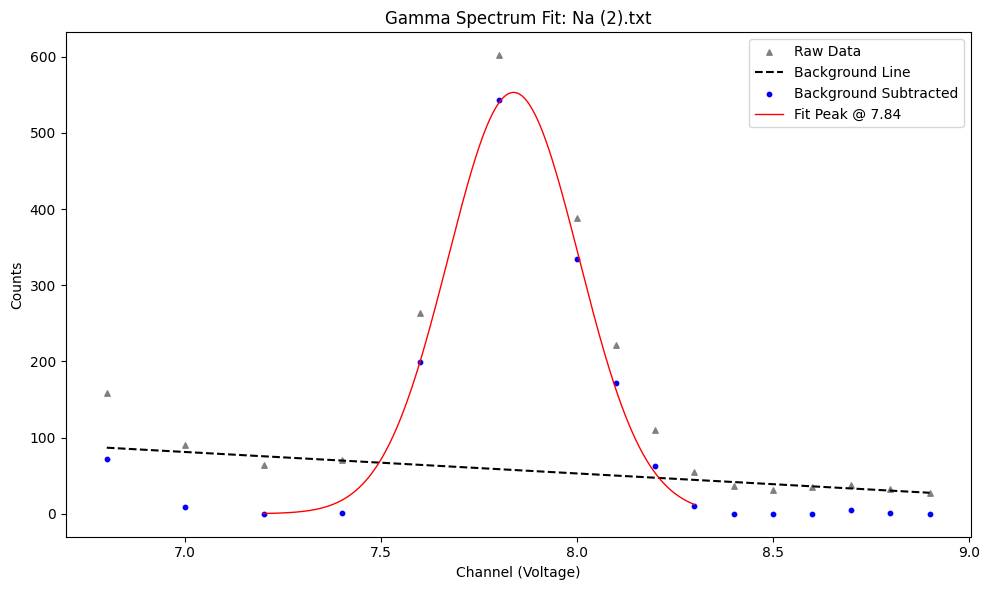

In [ ]:
# Gamma Spectroscopy Efficiency Calculation (Single File)

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import math
from google.colab import files as fil

# Gaussian function
def gaussian(x, a, mean, sigma):
    return a * np.exp(-((x - mean) ** 2) / (2 * sigma ** 2))

# Read data from file
def read_data(file):
    x_data, y_data = [], []
    with open(file, "r") as f:
        for line in f:
            if line.strip():
                columns = line.split()
                if len(columns) >= 2:
                    x_data.append(float(columns[0]))
                    y_data.append(float(columns[1]))
    return np.array(x_data), np.array(y_data)

# File upload
uploaded = fil.upload()
file = list(uploaded.keys())[0]

# User inputs
activity = float(input("Enter the current activity of the source in Bq: "))
decay_fraction = [float(i) for i in input("Enter decay fractions (comma-separated, one per peak): ").split(",")]
measurement_time = float(input("Enter the measurement time in seconds: "))
solid_angle = float(input("Enter solid angle in steradians: "))

# Peak estimate inputs
means = [float(i) for i in input("Enter approximate peak positions (comma-separated): ").split(",")]
sigmas = [float(i) for i in input("Enter approximate sigmas (comma-separated, same order as peaks): ").split(",")]

# Read and preprocess data
x_data, y_data_raw = read_data(file)
y_err = np.sqrt(np.maximum(y_data_raw, 1e-5))

# Estimate background from the lowest points
lowest_indices = np.argsort(y_data_raw)[:10]
x_bg = x_data[lowest_indices]
y_bg = y_data_raw[lowest_indices]

# Fit background line
coeffs = np.polyfit(x_bg, y_bg, 1)
y_background = np.polyval(coeffs, x_data)

# Subtract background
y_subtracted = np.maximum(y_data_raw - y_background, 1e-5)

# Plot raw data and background
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data_raw, label='Raw Data', color='gray', marker='^', s=15)
plt.plot(x_data, y_background, label='Background Line', color='black', linestyle='--')
plt.scatter(x_data, y_subtracted, label='Background Subtracted', color='blue', s=10, marker='o')

# Fit Gaussian to each peak and calculate area
print(f"\nFile: {file}")
print(f"Activity: {activity:.2f} Bq\n")

colors = ['red', 'green', 'purple', 'orange', 'brown']  # for plotting individual peaks

for idx, (mean_est, sigma_est, df) in enumerate(zip(means, sigmas, decay_fraction)):
    mask = (x_data > mean_est - 3 * sigma_est) & (x_data < mean_est + 3 * sigma_est)
    x_fit = x_data[mask]
    y_fit = y_subtracted[mask]

    popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=[max(y_fit), mean_est, sigma_est])

    a_opt, mean_opt, sigma_opt = popt
    fitted_y = gaussian(x_fit, *popt)
    area = np.sum(fitted_y)

    abs_eff = area / (measurement_time * activity * df)
    intrinsic_eff = abs_eff * (4 * math.pi / solid_angle)

    # Plot the Gaussian fit
    x_smooth = np.linspace(min(x_fit), max(x_fit), 500)
    y_smooth = gaussian(x_smooth, *popt)
    plt.plot(x_smooth, y_smooth, label=f'Fit Peak @ {mean_opt:.2f}', linewidth=1, color=colors[idx % len(colors)])

    print(f"Peak at {mean_opt:.2f}:")
    print(f"  Area (total counts under peak) = {area:.2f}")
    print(f"  Decay fraction = {df}")
    print(f"  Absolute efficiency = {abs_eff*100:.4f}%")
    print(f"  Intrinsic efficiency = {intrinsic_eff*100:.4f}%\n")

plt.xlabel('Channel (Voltage)')
plt.ylabel('Counts')
plt.title(f'Gamma Spectrum Fit: {file}')
plt.legend()
plt.tight_layout()
plt.show()

Saving 1.2 Cs.txt to 1.2 Cs (6).txt
Enter the current activity of the source in Bq: 73813
Enter decay fractions (comma-separated, one per peak): 0.8480
Enter the measurement time in seconds: 60
Enter solid angle in steradians: 3.599
Enter approximate peak positions (comma-separated): 4.33
Enter approximate sigmas (comma-separated, same order as peaks): 0.2

File: 1.2 Cs (6).txt
Activity: 73813.00 Bq

Peak at 4.33:
  Area (total counts under peak) = 34572.49
  Decay fraction = 0.848
  Absolute efficiency = 0.9206%
  Intrinsic efficiency = 3.2142%



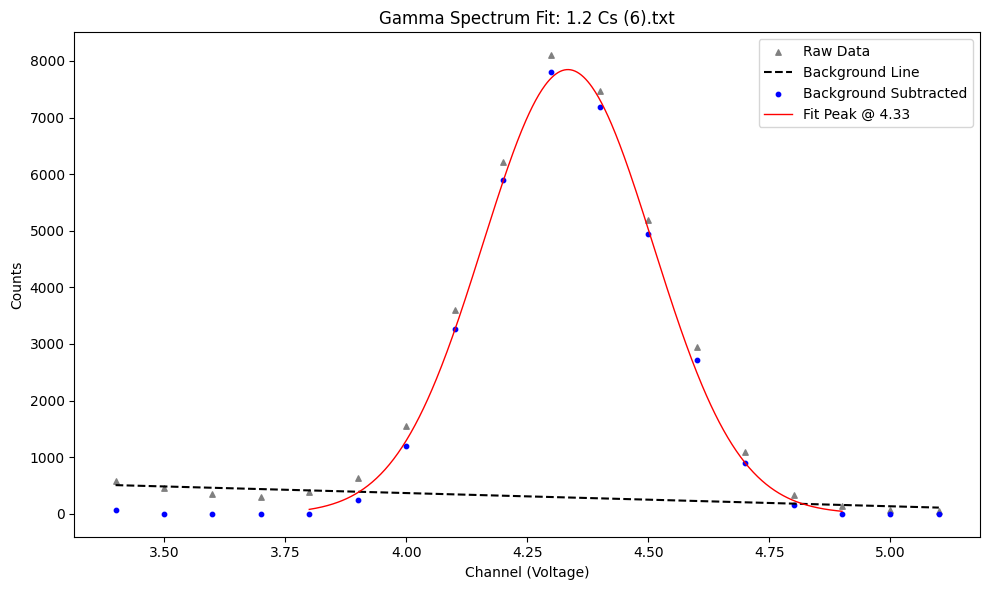

In [ ]:
# Gamma Spectroscopy Efficiency Calculation (Single File)

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import math
from google.colab import files as fil

# Gaussian function
def gaussian(x, a, mean, sigma):
    return a * np.exp(-((x - mean) ** 2) / (2 * sigma ** 2))

# Read data from file
def read_data(file):
    x_data, y_data = [], []
    with open(file, "r") as f:
        for line in f:
            if line.strip():
                columns = line.split()
                if len(columns) >= 2:
                    x_data.append(float(columns[0]))
                    y_data.append(float(columns[1]))
    return np.array(x_data), np.array(y_data)

# File upload
uploaded = fil.upload()
file = list(uploaded.keys())[0]

# User inputs
activity = float(input("Enter the current activity of the source in Bq: "))
decay_fraction = [float(i) for i in input("Enter decay fractions (comma-separated, one per peak): ").split(",")]
measurement_time = float(input("Enter the measurement time in seconds: "))
solid_angle = float(input("Enter solid angle in steradians: "))

# Peak estimate inputs
means = [float(i) for i in input("Enter approximate peak positions (comma-separated): ").split(",")]
sigmas = [float(i) for i in input("Enter approximate sigmas (comma-separated, same order as peaks): ").split(",")]

# Read and preprocess data
x_data, y_data_raw = read_data(file)
y_err = np.sqrt(np.maximum(y_data_raw, 1e-5))

# Estimate background from the lowest points
lowest_indices = np.argsort(y_data_raw)[:10]
x_bg = x_data[lowest_indices]
y_bg = y_data_raw[lowest_indices]

# Fit background line
coeffs = np.polyfit(x_bg, y_bg, 1)
y_background = np.polyval(coeffs, x_data)

# Subtract background
y_subtracted = np.maximum(y_data_raw - y_background, 1e-5)

# Plot raw data and background
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data_raw, label='Raw Data', color='gray', marker='^', s=15)
plt.plot(x_data, y_background, label='Background Line', color='black', linestyle='--')
plt.scatter(x_data, y_subtracted, label='Background Subtracted', color='blue', s=10, marker='o')

# Fit Gaussian to each peak and calculate area
print(f"\nFile: {file}")
print(f"Activity: {activity:.2f} Bq\n")

colors = ['red', 'green', 'purple', 'orange', 'brown']  # for plotting individual peaks

for idx, (mean_est, sigma_est, df) in enumerate(zip(means, sigmas, decay_fraction)):
    mask = (x_data > mean_est - 3 * sigma_est) & (x_data < mean_est + 3 * sigma_est)
    x_fit = x_data[mask]
    y_fit = y_subtracted[mask]

    popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=[max(y_fit), mean_est, sigma_est])

    a_opt, mean_opt, sigma_opt = popt
    fitted_y = gaussian(x_fit, *popt)
    area = np.sum(fitted_y)

    abs_eff = area / (measurement_time * activity * df)
    intrinsic_eff = abs_eff * (4 * math.pi / solid_angle)

    # Plot the Gaussian fit
    x_smooth = np.linspace(min(x_fit), max(x_fit), 500)
    y_smooth = gaussian(x_smooth, *popt)
    plt.plot(x_smooth, y_smooth, label=f'Fit Peak @ {mean_opt:.2f}', linewidth=1, color=colors[idx % len(colors)])

    print(f"Peak at {mean_opt:.2f}:")
    print(f"  Area (total counts under peak) = {area:.2f}")
    print(f"  Decay fraction = {df}")
    print(f"  Absolute efficiency = {abs_eff*100:.4f}%")
    print(f"  Intrinsic efficiency = {intrinsic_eff*100:.4f}%\n")

plt.xlabel('Channel (Voltage)')
plt.ylabel('Counts')
plt.title(f'Gamma Spectrum Fit: {file}')
plt.legend()
plt.tight_layout()
plt.show()

Saving 1.2 Co.txt to 1.2 Co (1).txt
Enter the current activity of the source in Bq: 17200
Enter decay fractions (comma-separated, one per peak): 7.25
Enter the measurement time in seconds: 60
Enter solid angle in steradians: 3.599
Enter approximate peak positions (comma-separated): 7.25
Enter approximate sigmas (comma-separated, same order as peaks): 0.2

File: 1.2 Co (1).txt
Activity: 17200.00 Bq

Peak at 7.32:
  Area (total counts under peak) = 2316.07
  Decay fraction = 7.25
  Absolute efficiency = 0.0310%
  Intrinsic efficiency = 0.1081%



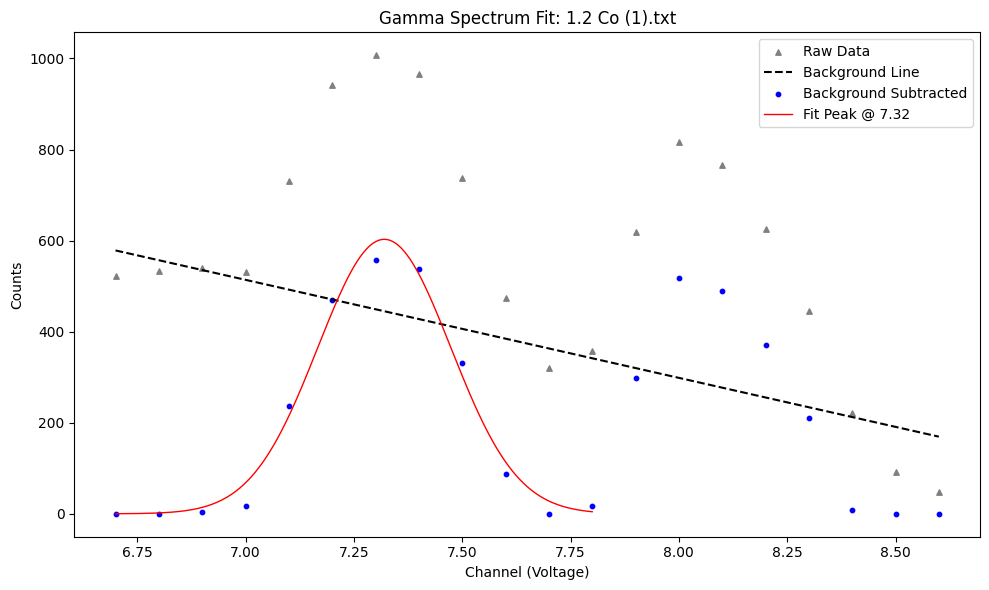


Resolved Peaks:
Peak 1 at 7.32:
  Area = 3.86 counts/sec
  Decay fraction = 7.25
  Absolute efficiency = 0.0031%
  Intrinsic efficiency = 0.0108%



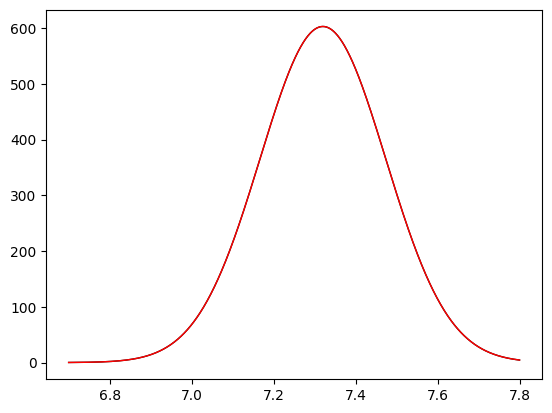

In [ ]:
# Gamma Spectroscopy Efficiency Calculation (Single File)

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import math
from google.colab import files as fil

# Gaussian function
def gaussian(x, a, mean, sigma):
    return a * np.exp(-((x - mean) ** 2) / (2 * sigma ** 2))

# Read data from file
def read_data(file):
    x_data, y_data = [], []
    with open(file, "r") as f:
        for line in f:
            if line.strip():
                columns = line.split()
                if len(columns) >= 2:
                    x_data.append(float(columns[0]))
                    y_data.append(float(columns[1]))
    return np.array(x_data), np.array(y_data)

# File upload
uploaded = fil.upload()
file = list(uploaded.keys())[0]

# User inputs
activity = float(input("Enter the current activity of the source in Bq: "))
decay_fraction = [float(i) for i in input("Enter decay fractions (comma-separated, one per peak): ").split(",")]
measurement_time = float(input("Enter the measurement time in seconds: "))
solid_angle = float(input("Enter solid angle in steradians: "))

# Peak estimate inputs
means = [float(i) for i in input("Enter approximate peak positions (comma-separated): ").split(",")]
sigmas = [float(i) for i in input("Enter approximate sigmas (comma-separated, same order as peaks): ").split(",")]

# Read and preprocess data
x_data, y_data_raw = read_data(file)
y_err = np.sqrt(np.maximum(y_data_raw, 1e-5))

# Estimate background from the lowest points
lowest_indices = np.argsort(y_data_raw)[:10]
x_bg = x_data[lowest_indices]
y_bg = y_data_raw[lowest_indices]

# Fit background line
coeffs = np.polyfit(x_bg, y_bg, 1)
y_background = np.polyval(coeffs, x_data)

# Subtract background
y_subtracted = np.maximum(y_data_raw - y_background, 1e-5)

# Plot raw data and background
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data_raw, label='Raw Data', color='gray', marker='^', s=15)
plt.plot(x_data, y_background, label='Background Line', color='black', linestyle='--')
plt.scatter(x_data, y_subtracted, label='Background Subtracted', color='blue', s=10, marker='o')

# Fit Gaussian to each peak and calculate area
print(f"\nFile: {file}")
print(f"Activity: {activity:.2f} Bq\n")

colors = ['red', 'green', 'purple', 'orange', 'brown']  # for plotting individual peaks

for idx, (mean_est, sigma_est, df) in enumerate(zip(means, sigmas, decay_fraction)):
    mask = (x_data > mean_est - 3 * sigma_est) & (x_data < mean_est + 3 * sigma_est)
    x_fit = x_data[mask]
    y_fit = y_subtracted[mask]

    popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=[max(y_fit), mean_est, sigma_est])

    a_opt, mean_opt, sigma_opt = popt
    fitted_y = gaussian(x_fit, *popt)
    area = np.sum(fitted_y)

    abs_eff = area / (measurement_time * activity * df)
    intrinsic_eff = abs_eff * (4 * math.pi / solid_angle)

    # Plot the Gaussian fit
    x_smooth = np.linspace(min(x_fit), max(x_fit), 500)
    y_smooth = gaussian(x_smooth, *popt)
    plt.plot(x_smooth, y_smooth, label=f'Fit Peak @ {mean_opt:.2f}', linewidth=1, color=colors[idx % len(colors)])

    print(f"Peak at {mean_opt:.2f}:")
    print(f"  Area (total counts under peak) = {area:.2f}")
    print(f"  Decay fraction = {df}")
    print(f"  Absolute efficiency = {abs_eff*100:.4f}%")
    print(f"  Intrinsic efficiency = {intrinsic_eff*100:.4f}%\n")

plt.xlabel('Channel (Voltage)')
plt.ylabel('Counts')
plt.title(f'Gamma Spectrum Fit: {file}')
plt.legend()
plt.tight_layout()
plt.show()
# Fit multiple Gaussians simultaneously
def multi_gaussian(x, *params):
    n = len(params) // 3
    y = np.zeros_like(x)
    for i in range(n):
        a, m, s = params[3*i:3*i+3]
        y += gaussian(x, a, m, s)
    return y

# Combine all peaks for fitting
fit_mask = np.zeros_like(x_data, dtype=bool)
for m, s in zip(means, sigmas):
    fit_mask |= (x_data > m - 3 * s) & (x_data < m + 3 * s)
x_fit = x_data[fit_mask]
y_fit = y_subtracted[fit_mask]

# Initial guess
initial_guess = []
for m, s in zip(means, sigmas):
    a = max(y_subtracted[(x_data > m - s) & (x_data < m + s)])
    initial_guess += [a, m, s]

# Fit the combined function
popt, pcov = curve_fit(multi_gaussian, x_fit, y_fit, p0=initial_guess)

# Plot each fitted Gaussian and compute area
x_smooth = np.linspace(min(x_fit), max(x_fit), 1000)
y_total = multi_gaussian(x_smooth, *popt)
plt.plot(x_smooth, y_total, label='Total Fit', color='black', linewidth=1)

print(f"\nResolved Peaks:")

for i in range(len(means)):
    a_opt, m_opt, s_opt = popt[3*i:3*i+3]
    y_single = gaussian(x_smooth, a_opt, m_opt, s_opt)
    plt.plot(x_smooth, y_single, label=f'Peak {i+1} @ {m_opt:.2f}', linewidth=1, color=colors[i % len(colors)])

    area = a_opt * s_opt * np.sqrt(2 * np.pi)
    df = decay_fraction[i]

    abs_eff = area / (measurement_time * activity * df)
    intrinsic_eff = abs_eff * (4 * math.pi / solid_angle)

    print(f"Peak {i+1} at {m_opt:.2f}:")
    print(f"  Area = {area / measurement_time:.2f} counts/sec")
    print(f"  Decay fraction = {df}")
    print(f"  Absolute efficiency = {abs_eff*100:.4f}%")
    print(f"  Intrinsic efficiency = {intrinsic_eff*100:.4f}%\n")

Saving 1.2 Cs.txt to 1.2 Cs (1).txt
Enter the current activity of the source in Bq: 73860
Enter decay fractions (comma-separated, one per peak): 0.8480
Enter the measurement time in seconds: 60
Enter solid angle in steradians: 2.116
Enter approximate peak positions (comma-separated): 4.2
Enter approximate sigmas (comma-separated, same order as peaks): 0.2

File: 1.2 Cs (1).txt
Activity: 73860.00 Bq

Peak at 4.33:
  Area (total counts under peak) = 34543.40
  Decay fraction = 0.848
  Absolute efficiency = 0.9192%
  Intrinsic efficiency = 5.4589%



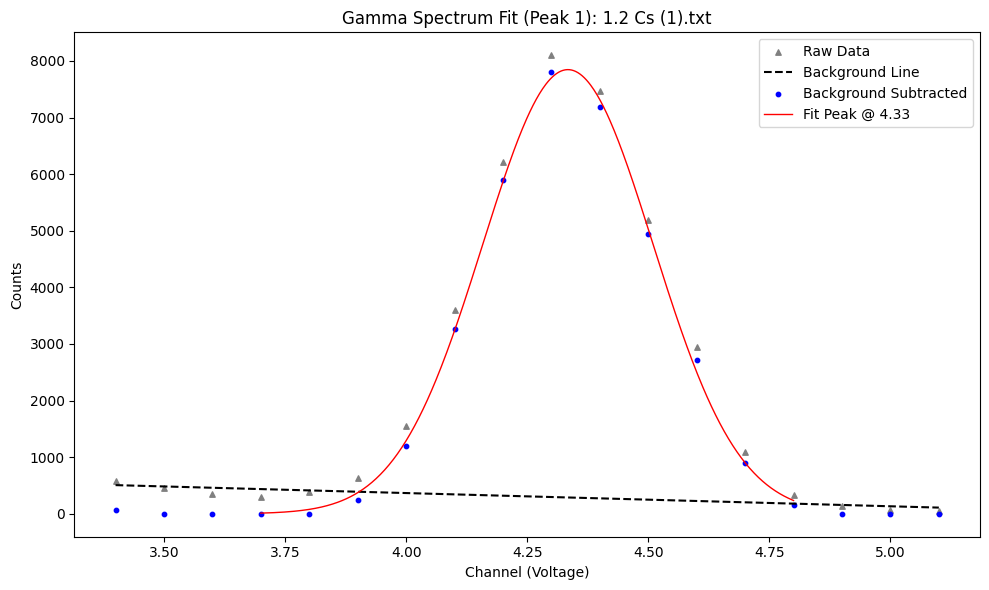


Resolved Peaks:
Peak 1 at 4.33:
  Area = 57.66 counts/sec
  Decay fraction = 0.848
  Absolute efficiency = 0.0921%
  Intrinsic efficiency = 0.5467%



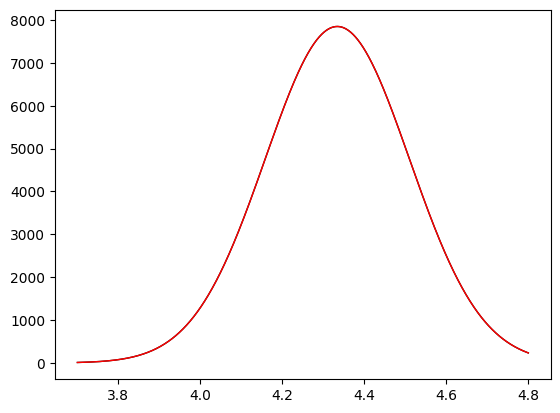

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import math
from google.colab import files as fil

# Gaussian function
def gaussian(x, a, mean, sigma):
    return a * np.exp(-((x - mean) ** 2) / (2 * sigma ** 2))

# Read data from file
def read_data(file):
    x_data, y_data = [], []
    with open(file, "r") as f:
        for line in f:
            if line.strip():
                columns = line.split()
                if len(columns) >= 2:
                    x_data.append(float(columns[0]))
                    y_data.append(float(columns[1]))
    return np.array(x_data), np.array(y_data)

# File upload
uploaded = fil.upload()
file = list(uploaded.keys())[0]

# User inputs
activity = float(input("Enter the current activity of the source in Bq: "))
decay_fraction = [float(i) for i in input("Enter decay fractions (comma-separated, one per peak): ").split(",")]
measurement_time = float(input("Enter the measurement time in seconds: "))
solid_angle = float(input("Enter solid angle in steradians: "))

# Peak estimate inputs
means = [float(i) for i in input("Enter approximate peak positions (comma-separated): ").split(",")]
sigmas = [float(i) for i in input("Enter approximate sigmas (comma-separated, same order as peaks): ").split(",")]

# Read and preprocess data
x_data, y_data_raw = read_data(file)
y_err = np.sqrt(np.maximum(y_data_raw, 1e-5))

# Estimate background from the lowest points
lowest_indices = np.argsort(y_data_raw)[:10]
x_bg = x_data[lowest_indices]
y_bg = y_data_raw[lowest_indices]

# Fit background line
coeffs = np.polyfit(x_bg, y_bg, 1)
y_background = np.polyval(coeffs, x_data)

# Subtract background
y_subtracted = np.maximum(y_data_raw - y_background, 1e-5)

# Plot raw data and background
plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data_raw, label='Raw Data', color='gray', marker='^', s=15)
plt.plot(x_data, y_background, label='Background Line', color='black', linestyle='--')
plt.scatter(x_data, y_subtracted, label='Background Subtracted', color='blue', s=10, marker='o')

# Fit Gaussian to each peak and calculate area
print(f"\nFile: {file}")
print(f"Activity: {activity:.2f} Bq\n")

colors = ['red', 'green', 'purple', 'orange', 'brown']  # for plotting individual peaks

for idx, (mean_est, sigma_est, df) in enumerate(zip(means, sigmas, decay_fraction)):
    mask = (x_data > mean_est - 3 * sigma_est) & (x_data < mean_est + 3 * sigma_est)
    x_fit = x_data[mask]
    y_fit = y_subtracted[mask]

    popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=[max(y_fit), mean_est, sigma_est])

    a_opt, mean_opt, sigma_opt = popt
    fitted_y = gaussian(x_fit, *popt)
    area = np.sum(fitted_y)

    abs_eff = area / (measurement_time * activity * df)
    intrinsic_eff = abs_eff * (4 * math.pi / solid_angle)

    # Plot the Gaussian fit
    x_smooth = np.linspace(min(x_fit), max(x_fit), 500)
    y_smooth = gaussian(x_smooth, *popt)
    plt.plot(x_smooth, y_smooth, label=f'Fit Peak @ {mean_opt:.2f}', linewidth=1, color=colors[idx % len(colors)])

    print(f"Peak at {mean_opt:.2f}:")
    print(f"  Area (total counts under peak) = {area:.2f}")
    print(f"  Decay fraction = {df}")
    print(f"  Absolute efficiency = {abs_eff*100:.4f}%")
    print(f"  Intrinsic efficiency = {intrinsic_eff*100:.4f}%\n")

plt.xlabel('Channel (Voltage)')
plt.ylabel('Counts')
plt.title(f'Gamma Spectrum Fit (Peak {idx + 1}): {file}')
plt.legend()
plt.tight_layout()
plt.show()
# Fit multiple Gaussians simultaneously
def multi_gaussian(x, *params):
    n = len(params) // 3
    y = np.zeros_like(x)
    for i in range(n):
        a, m, s = params[3*i:3*i+3]
        y += gaussian(x, a, m, s)
    return y

# Combine all peaks for fitting
fit_mask = np.zeros_like(x_data, dtype=bool)
for m, s in zip(means, sigmas):
    fit_mask |= (x_data > m - 3 * s) & (x_data < m + 3 * s)
x_fit = x_data[fit_mask]
y_fit = y_subtracted[fit_mask]

# Initial guess
initial_guess = []
for m, s in zip(means, sigmas):
    a = max(y_subtracted[(x_data > m - s) & (x_data < m + s)])
    initial_guess += [a, m, s]

# Fit the combined function
popt, pcov = curve_fit(multi_gaussian, x_fit, y_fit, p0=initial_guess)

# Plot each fitted Gaussian and compute area
x_smooth = np.linspace(min(x_fit), max(x_fit), 1000)
y_total = multi_gaussian(x_smooth, *popt)
plt.plot(x_smooth, y_total, label='Total Fit', color='black', linewidth=1)

print(f"\nResolved Peaks:")

for i in range(len(means)):
    a_opt, m_opt, s_opt = popt[3*i:3*i+3]
    y_single = gaussian(x_smooth, a_opt, m_opt, s_opt)
    plt.plot(x_smooth, y_single, label=f'Peak {i+1} @ {m_opt:.2f}', linewidth=1, color=colors[i % len(colors)])

    area = a_opt * s_opt * np.sqrt(2 * np.pi)
    df = decay_fraction[i]

    abs_eff = area / (measurement_time * activity * df)
    intrinsic_eff = abs_eff * (4 * math.pi / solid_angle)

    print(f"Peak {i+1} at {m_opt:.2f}:")
    print(f"  Area = {area / measurement_time:.2f} counts/sec")
    print(f"  Decay fraction = {df}")
    print(f"  Absolute efficiency = {abs_eff*100:.4f}%")
    print(f"  Intrinsic efficiency = {intrinsic_eff*100:.4f}%\n")

